In [1]:
#Importing nacessary libraries for Data analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Setting the visual theme for charts
sns.set_theme(style="whitegrid")

In [2]:
import pandas as pd

# Using 'windows-1252' encoding to prevent reading errors common in Kaggle CSV files
df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

#Displaying the first 5 rows to ensure data is loaded correctly
print('Data loaded successfully! here are the first 5 rows: ')
display(df.head())

Data loaded successfully! here are the first 5 rows: 


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:

#converting 'Order Data' and 'Ship Data' from text to proper datatime format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# checking for missing values in the dataset
print('Missing values in each column:')
print(df.isnull().sum())

# Displaying the basic information about the dataset
print("\nDataset Info:")
df.info()

Missing values in each column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   st

Category wise Sales and Profit:


,Category,Sales,Profit
0,Furniture,741999.7953,18451.2728
1,Office Supplies,719047.0320,122490.8008
2,Technology,836154.0330,145454.9481


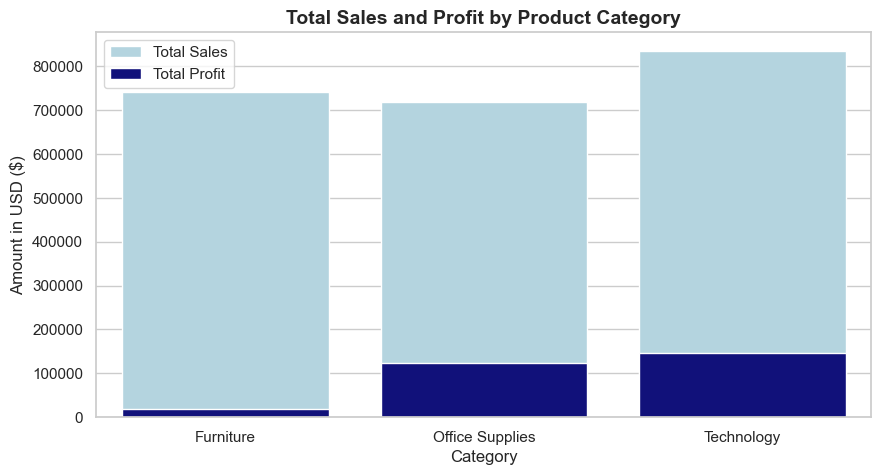

In [4]:
#Analyzing Sales and Profit by Category
#Grouping data to find which category generates the highest revenue and profit
category_analysis = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
#Display the summary table
print("Category wise Sales and Profit:")
display(category_analysis)
#Visualizing the results using a Bar Chart
plt.figure(figsize=(10 , 5))
#Plot Sales for comparison
sns.barplot(x='Category', y='Sales', data=category_analysis, color='lightblue',label='Total Sales')
#Plot Profit for comparison
sns.barplot(x='Category', y='Profit', data=category_analysis, color='darkblue',label='Total Profit')

#Formatting the chart for better readability
plt.title('Total Sales and Profit by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Amount in USD ($)', fontsize=12)
plt.legend()
plt.show()

Loss_Making Sub-Categories:


,Sub-Category,Profit
16,Tables,-17725.4811
4,Bookcases,-3472.5560
15,Supplies,-1189.0995


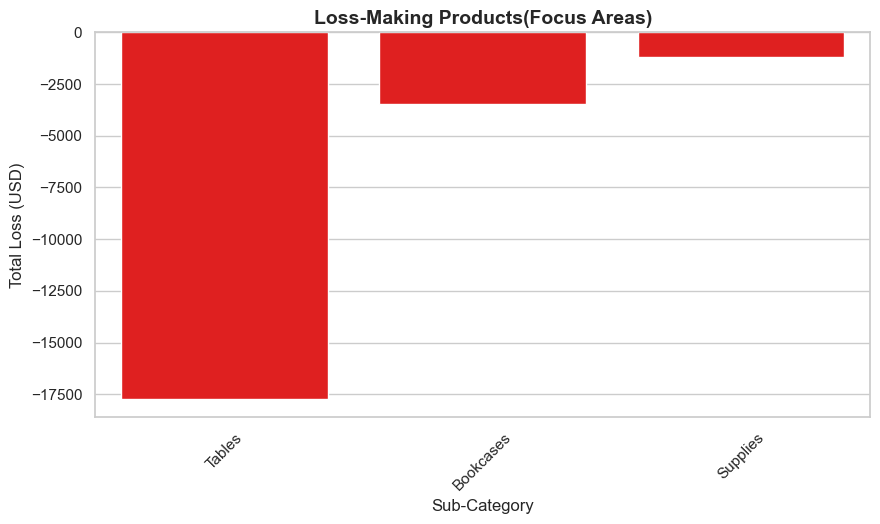

In [5]:
#Identifying Loss-Making Products 
#Grouping data by Sub-Category to find where the business is losing money
subcat_profit = df.groupby('Sub-Category')[['Profit']].sum().reset_index()
#Filtering for products with negative profit (loss)
loss_making = subcat_profit[subcat_profit['Profit']<0].sort_values(by='Profit')
print('Loss_Making Sub-Categories:')
display(loss_making)
#Visualizing the loss areas
plt.figure(figsize=(10, 5))
sns.barplot(x='Sub-Category',y='Profit',data=loss_making,color='red')
plt.title('Loss-Making Products(Focus Areas)',fontsize=14,fontweight='bold')
plt.xlabel('Sub-Category',fontsize=12)
plt.ylabel('Total Loss (USD)',fontsize=12)
plt.xticks(rotation=45)
#Rotating text so names don't overlap
plt.show()

Top 10 Best-Selling Products:


,Product Name,Quantity
1499,Staples,215
1493,Staple envelope,170
537,Easy-staple paper,150
1500,Staples in misc. colors,86
942,KI Adjustable-Height Table,74
1511,Storex Dura Pro Binders,71
259,Avery Non-Stick Binders,71
699,GBC Premium Transparent Covers with Diagonal L...,67
1450,"Situations Contoured Folding Chairs, 4/Set",64
1497,Staple-based wall hangings,62


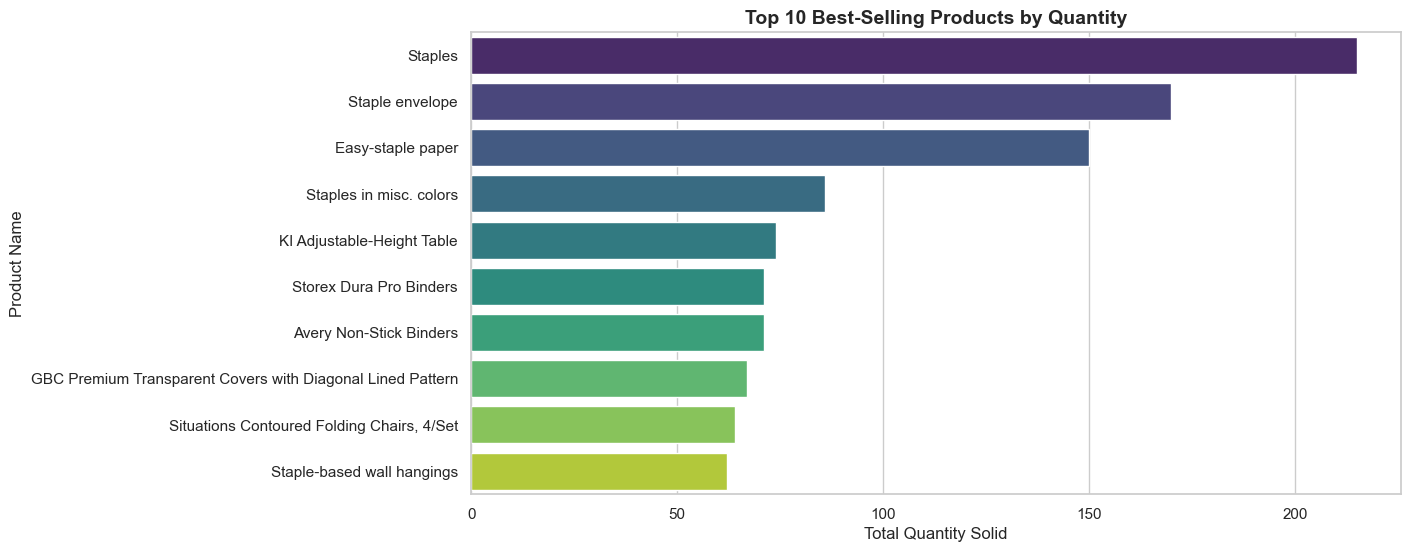

In [6]:
#Top 10 Best-Selling Products
#Groping data by Product Name to see which item sell the highest quantity
top_products = df.groupby('Product Name')[['Quantity']].sum().reset_index()

#Sorting the data from highest to lowest and taking only the top 10
top_products = top_products.sort_values(by='Quantity',ascending=False).head(10)
print("Top 10 Best-Selling Products:")
display(top_products)

#Visualizing the Top 10 Products
plt.figure(figsize=(12, 6))
sns.barplot(y='Product Name', x='Quantity', data=top_products, palette='viridis',hue='Product Name', legend=False)

plt.title('Top 10 Best-Selling Products by Quantity', fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity Solid', fontsize =12)
plt.ylabel('Product Name',fontsize=12)
plt.show()

In [7]:
#Export Cleaned data for Power BI/SQl
df.to_csv('Cleaned_Superstore_Data.csv',index=False)
print("Cleaned data saved as 'Cleaned_Superstore_Data.csv'")

Cleaned data saved as 'Cleaned_Superstore_Data.csv'
